# Evaluation & Metrics
## Gut Microbiome Project · Bar-Ilan University

Comprehensive evaluation of all models built in `modeling.ipynb`.

| Section | Task | Metrics |
|---|---|---|
| 1 | Food Group Classification (10-class) | Accuracy, F1-macro, AUC-ROC, per-class report, learning curve |
| 2 | Fermented vs Non-Fermented (binary) | Accuracy, F1, AUC-ROC, Precision-Recall curve |
| 3 | Gut Health Score Regression | R², MAE, RMSE, residual analysis, per-participant |
| 4 | Good vs Bad Gut Day (binary) | Accuracy, F1, AUC-ROC, cross-validation |
| 5 | Food Ranking Validation | Bootstrap CIs, significance, stability |
| 6 | Overall Summary | All models compared in one table |


In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    StratifiedKFold, KFold, cross_val_score,
    train_test_split, learning_curve
)
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    r2_score, mean_absolute_error, mean_squared_error
)
from IPython.display import display

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

warnings.filterwarnings('once')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

def find_repo_root():
    for p in [Path.cwd()] + list(Path.cwd().parents):
        if (p / 'master_metadata.tsv').exists():
            return p
    raise FileNotFoundError('Cannot find repo root')

REPO_ROOT = find_repo_root()
DIET_ROOT = REPO_ROOT / 'dietstudy_analyses-master'
print(f'SHAP available: {SHAP_AVAILABLE}')
print('All imports OK.')

SHAP available: False
All imports OK.


## Data Loading


In [2]:
# Dataset 1
d1 = pd.read_csv(REPO_ROOT / 'features_dataset1.csv', index_col=0)
feat_cols_d1 = [c for c in d1.columns if c not in ['food_group','fermented_binary']]
X1        = d1[feat_cols_d1].fillna(0)
y_group   = d1['food_group']
y_ferment = d1['fermented_binary'].fillna(0).astype(int)
le        = LabelEncoder()
y_grp_enc = le.fit_transform(y_group)

# Dataset 2
d2 = pd.read_csv(REPO_ROOT / 'features_dataset2.csv')
BENEFICIAL = ['Bifidobacterium','Faecalibacterium','Akkermansia','Lactobacillus']
score_parts = []
for col in [f'dCLR_{t}' for t in BENEFICIAL] + ['Delta_EntTaxa']:
    if col in d2.columns:
        score_parts.append((d2[col] - d2[col].mean()) / (d2[col].std() + 1e-9))
d2['GutHealthScore'] = pd.concat(score_parts, axis=1).mean(axis=1)
d2['GoodGutDay']     = (d2['GutHealthScore'] > 0).astype(int)

# Specific-food matrix
FOOD_DIR = DIET_ROOT / 'data' / 'procrustes' / 'data_username_1day'
MIN_OBS  = 15
logs = []
for fp in sorted(FOOD_DIR.glob('*_food.txt')):
    tmp = pd.read_csv(fp, sep='\t')
    sid_cols = [c for c in tmp.columns if c not in ['#FoodID','taxonomy']]
    tl = tmp.melt(id_vars=['#FoodID','taxonomy'], value_vars=sid_cols,
                  var_name='PrevSampleID', value_name='Grams')
    tl['Grams'] = pd.to_numeric(tl['Grams'], errors='coerce')
    tl = tl.loc[tl['Grams'] > 0]
    tl['Food_Name'] = tl['taxonomy'].apply(
        lambda t: str(t).split(';')[-1].strip() if pd.notna(t) else 'Unknown')
    logs.append(tl[['PrevSampleID','Food_Name','Grams']])
diet_long = pd.concat(logs, ignore_index=True)
diet_long['PrevSampleID'] = diet_long['PrevSampleID'].astype(str)

valid_prev = set(d2['PrevSampleID'].astype(str))
diet_long  = diet_long.loc[diet_long['PrevSampleID'].isin(valid_prev)]
food_obs   = diet_long.groupby('Food_Name')['PrevSampleID'].nunique()
common_foods = food_obs[food_obs >= MIN_OBS].index
diet_filt  = diet_long.loc[diet_long['Food_Name'].isin(common_foods)]
food_matrix = (
    diet_filt.groupby(['PrevSampleID','Food_Name'])['Grams']
    .sum().unstack(fill_value=0)
)
food_matrix.columns.name = None

d2_str = d2.copy()
d2_str['PrevSampleID'] = d2_str['PrevSampleID'].astype(str)
model_df  = d2_str.join(food_matrix, on='PrevSampleID', how='inner')
food_cols = list(common_foods)
nutr_cols = [c for c in model_df.columns if c.startswith('nutr_')]
X_food    = model_df[food_cols].fillna(0)
X_full    = pd.concat([X_food, model_df[nutr_cols + ['Supplement_MCT','StudyDayNo_norm']].fillna(0)], axis=1)
y_score   = model_df['GutHealthScore'].fillna(0)
y_good    = model_df['GoodGutDay'].fillna(0).astype(int)

print(f'D1: {X1.shape}  |  classes: {y_group.nunique()}')
print(f'D2 transitions: {len(model_df)}  |  food features: {len(food_cols)}')

D1: (3393, 80)  |  classes: 10
D2 transitions: 349  |  food features: 77


---
## Section 1 — Food Group Classification (10-class)


In [3]:
X1_tr, X1_te, yg_tr, yg_te = train_test_split(
    X1, y_grp_enc, test_size=0.2, stratify=y_grp_enc, random_state=RANDOM_SEED
)
rf1 = RandomForestClassifier(
    n_estimators=400, max_depth=None, class_weight='balanced',
    random_state=RANDOM_SEED, n_jobs=-1
)
rf1.fit(X1_tr, yg_tr)
yg_pred  = rf1.predict(X1_te)
yg_proba = rf1.predict_proba(X1_te)

acc1  = accuracy_score(yg_te, yg_pred)
f1m1  = f1_score(yg_te, yg_pred, average='macro')
f1w1  = f1_score(yg_te, yg_pred, average='weighted')
auc1  = roc_auc_score(yg_te, yg_proba, multi_class='ovr', average='macro')

print(f'Accuracy     : {acc1:.4f}')
print(f'F1-macro     : {f1m1:.4f}')
print(f'F1-weighted  : {f1w1:.4f}')
print(f'AUC-ROC (OvR): {auc1:.4f}')
print()
print('Per-class report:')
print(classification_report(yg_te, yg_pred, target_names=le.classes_, zero_division=0))

Accuracy     : 0.9249
F1-macro     : 0.8400
F1-weighted  : 0.9198
AUC-ROC (OvR): 0.9938

Per-class report:
                         precision    recall  f1-score   support

              Beverages       1.00      0.80      0.89        15
                 Cheese       0.91      0.99      0.94       338
Cocoa / fermented seeds       1.00      1.00      1.00        10
   Fermented vegetables       0.91      0.67      0.77        15
                   Fish       1.00      1.00      1.00        19
                  Kefir       0.97      0.96      0.96       135
                   Meat       1.00      0.96      0.98        53
            Other dairy       0.86      0.55      0.67        55
             Other food       0.89      0.91      0.90        35
                 Yogurt       0.33      0.25      0.29         4

               accuracy                           0.92       679
              macro avg       0.89      0.81      0.84       679
           weighted avg       0.92      0.92  

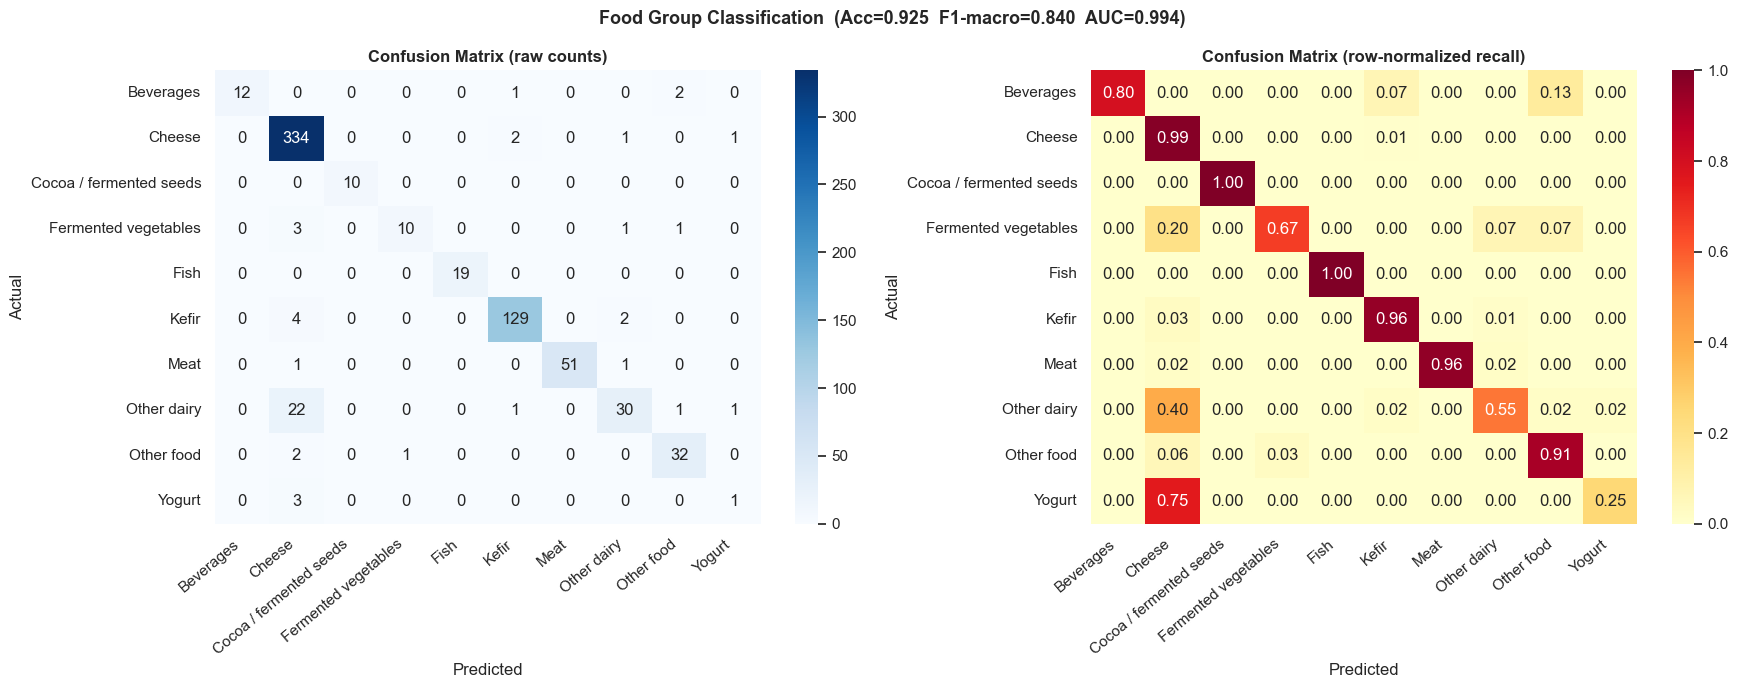

In [4]:
# Normalized confusion matrix
cm1 = confusion_matrix(yg_te, yg_pred)
cm1_norm = cm1.astype(float) / cm1.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix (raw counts)', weight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(le.classes_, rotation=40, ha='right')
axes[0].set_yticklabels(le.classes_, rotation=0)

sns.heatmap(cm1_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1],
            vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (row-normalized recall)', weight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
axes[1].set_xticklabels(le.classes_, rotation=40, ha='right')
axes[1].set_yticklabels(le.classes_, rotation=0)
plt.suptitle(f'Food Group Classification  (Acc={acc1:.3f}  F1-macro={f1m1:.3f}  AUC={auc1:.3f})',
             weight='bold', fontsize=13)
plt.tight_layout()
plt.show()

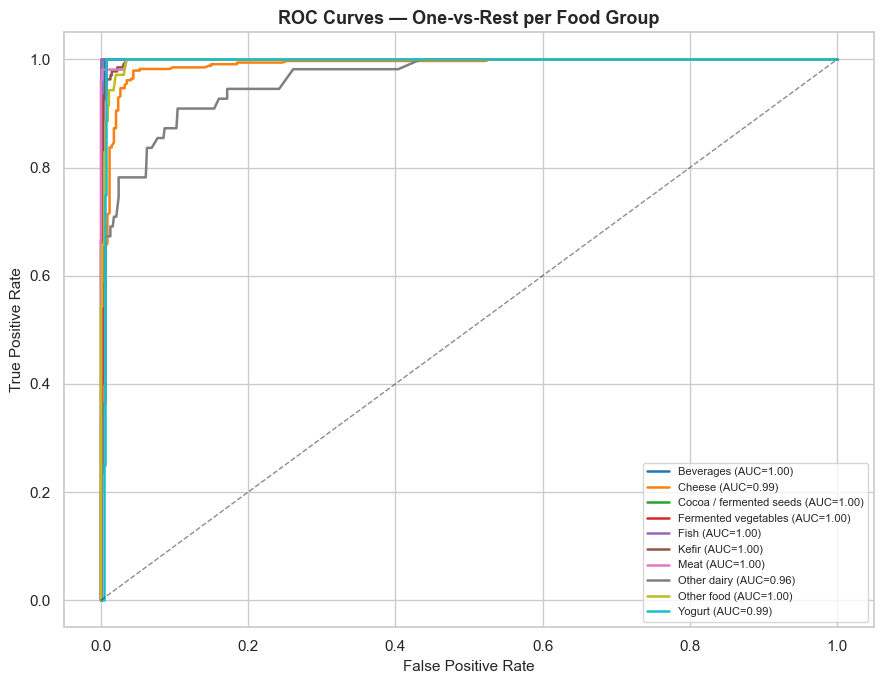

In [5]:
# ROC curves — one-vs-rest per class
classes   = le.classes_
n_classes = len(classes)
yg_bin    = label_binarize(yg_te, classes=list(range(n_classes)))

fig, ax = plt.subplots(figsize=(9, 7))
palette_roc = sns.color_palette('tab10', n_classes)
for i, (cls, color) in enumerate(zip(classes, palette_roc)):
    fpr, tpr, _ = roc_curve(yg_bin[:, i], yg_proba[:, i])
    roc_auc_i   = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=1.8,
            label=f'{cls} (AUC={roc_auc_i:.2f})')
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — One-vs-Rest per Food Group', weight='bold', fontsize=13)
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

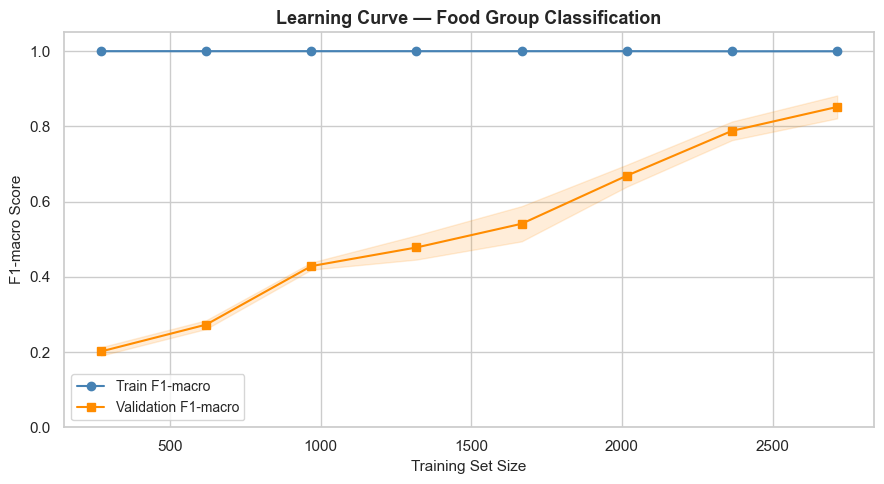

In [6]:
# Learning curve — how performance scales with training size
train_sizes, train_scores, val_scores = learning_curve(
    RandomForestClassifier(n_estimators=200, class_weight='balanced',
                            random_state=RANDOM_SEED, n_jobs=-1),
    X1, y_grp_enc,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_SEED),
    scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

tr_mean = train_scores.mean(axis=1)
tr_std  = train_scores.std(axis=1)
va_mean = val_scores.mean(axis=1)
va_std  = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(train_sizes, tr_mean-tr_std, tr_mean+tr_std, alpha=0.15, color='steelblue')
ax.fill_between(train_sizes, va_mean-va_std, va_mean+va_std, alpha=0.15, color='darkorange')
ax.plot(train_sizes, tr_mean, 'o-', color='steelblue',   label='Train F1-macro')
ax.plot(train_sizes, va_mean, 's-', color='darkorange', label='Validation F1-macro')
ax.set_xlabel('Training Set Size', fontsize=11)
ax.set_ylabel('F1-macro Score',    fontsize=11)
ax.set_title('Learning Curve — Food Group Classification', weight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

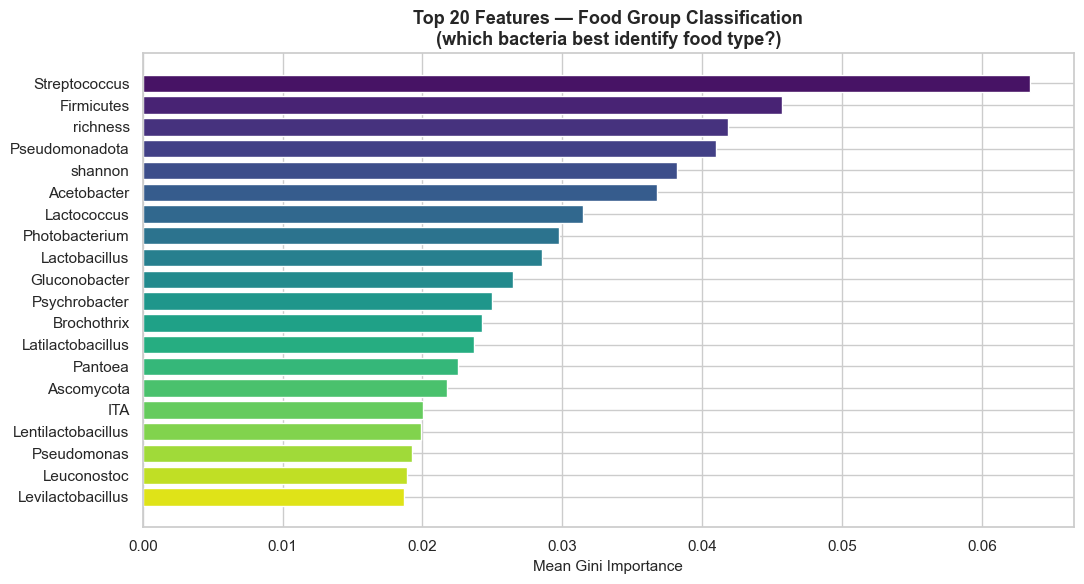

In [7]:
# Top-20 feature importances for food group model
imp_d1 = pd.Series(rf1.feature_importances_, index=X1.columns).sort_values(ascending=False)
top20  = imp_d1.head(20)

def short_label(name):
    for prefix in ['genus_','phylum_','country_','div_']:
        if name.startswith(prefix):
            return name.replace(prefix,'').replace('_',' ')[:30]
    return name[:30]

fig, ax = plt.subplots(figsize=(11, 6))
colors_imp = sns.color_palette('viridis_r', 20)
ax.barh([short_label(n) for n in top20.index[::-1]],
        top20.values[::-1], color=colors_imp)
ax.set_xlabel('Mean Gini Importance', fontsize=11)
ax.set_title('Top 20 Features — Food Group Classification\n(which bacteria best identify food type?)',
             weight='bold', fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 2 — Fermented vs Non-Fermented (Binary Classification)


Accuracy : 1.0000
F1-macro : 1.0000
AUC-ROC  : nan

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       679

    accuracy                           1.00       679
   macro avg       1.00      1.00      1.00       679
weighted avg       1.00      1.00      1.00       679



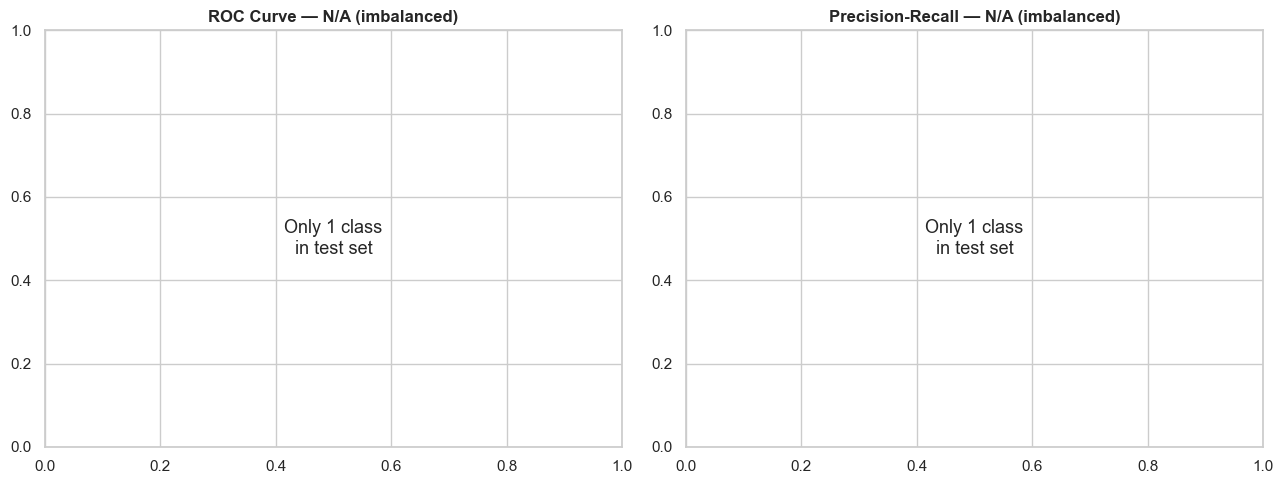

In [8]:
Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(
    X1, y_ferment, test_size=0.2, stratify=y_ferment, random_state=RANDOM_SEED
)
rf_bin = RandomForestClassifier(
    n_estimators=400, class_weight='balanced',
    random_state=RANDOM_SEED, n_jobs=-1
)
rf_bin.fit(Xf_tr, yf_tr)
yf_pred  = rf_bin.predict(Xf_te)
_proba   = rf_bin.predict_proba(Xf_te)
yf_proba = _proba[:, 1] if _proba.shape[1] >= 2 else _proba[:, 0]
has_two_classes = (len(np.unique(yf_te)) == 2) and (_proba.shape[1] >= 2)

acc_f  = accuracy_score(yf_te, yf_pred)
f1_f   = f1_score(yf_te, yf_pred, average='macro', zero_division=0)
try:
    auc_f = roc_auc_score(yf_te, yf_proba) if has_two_classes else float('nan')
except Exception:
    auc_f = float('nan')

print(f'Accuracy : {acc_f:.4f}')
print(f'F1-macro : {f1_f:.4f}')
print(f'AUC-ROC  : {auc_f:.4f}')
print()
print(classification_report(yf_te, yf_pred, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
if has_two_classes:
    fpr_f, tpr_f, _ = roc_curve(yf_te, yf_proba)
    axes[0].plot(fpr_f, tpr_f, color='steelblue', lw=2,
                 label=f'AUC = {auc_f:.3f}')
    axes[0].plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC Curve — Fermented vs Non-Fermented', weight='bold')
    axes[0].legend(fontsize=10)
else:
    axes[0].text(0.5, 0.5, 'Only 1 class\nin test set', ha='center', va='center', fontsize=13)
    axes[0].set_title('ROC Curve — N/A (imbalanced)', weight='bold')

# Precision-Recall
if has_two_classes:
    prec_f, rec_f, _ = precision_recall_curve(yf_te, yf_proba)
    ap_f = average_precision_score(yf_te, yf_proba)
    axes[1].plot(rec_f, prec_f, color='darkorange', lw=2,
                 label=f'Avg Precision = {ap_f:.3f}')
    axes[1].axhline(y_ferment.mean(), color='gray', linestyle='--',
                    label=f'Baseline = {y_ferment.mean():.3f}')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title('Precision-Recall Curve', weight='bold')
    axes[1].legend(fontsize=10)
else:
    axes[1].text(0.5, 0.5, 'Only 1 class\nin test set', ha='center', va='center', fontsize=13)
    axes[1].set_title('Precision-Recall — N/A (imbalanced)', weight='bold')
plt.tight_layout()
plt.show()

---
## Section 3 — Gut Health Score Regression

Can we predict the magnitude of the gut health score from what was eaten the day before?


R²              : -0.1105
MAE             : 0.3550
RMSE            : 0.4419
Pearson r       : -0.1118  (p=0.2998)


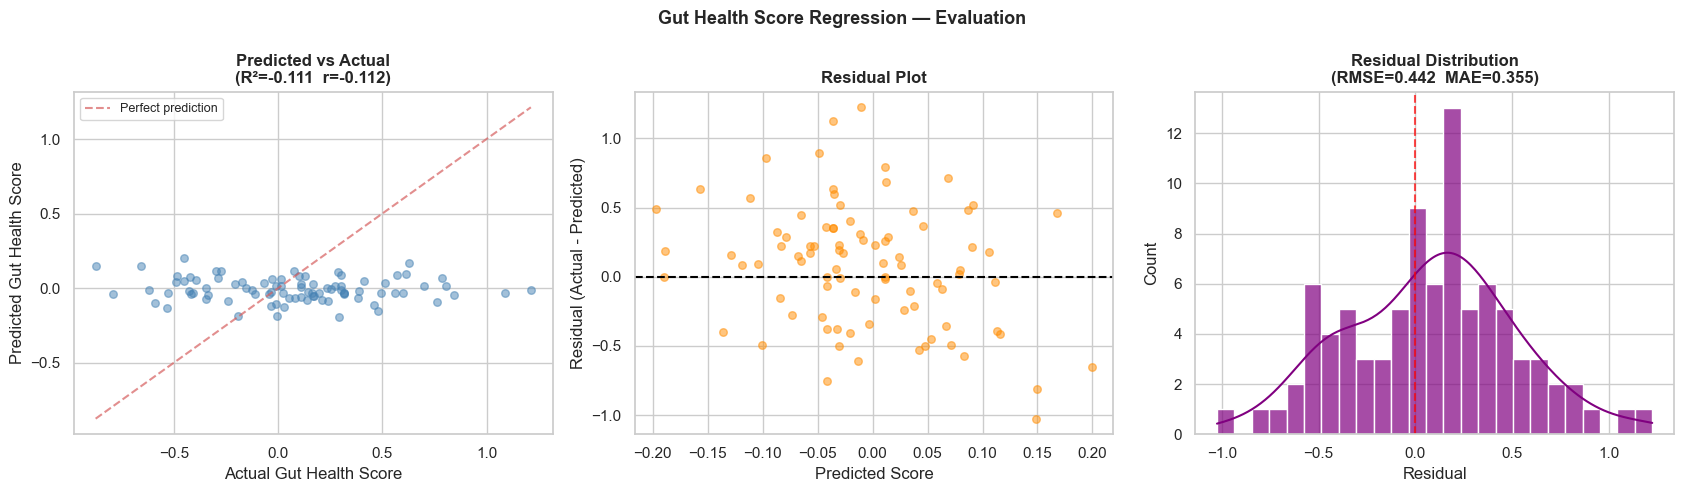

In [9]:
X_tr3, X_te3, ys_tr, ys_te = train_test_split(
    X_full, y_score, test_size=0.25, random_state=RANDOM_SEED
)
rf_reg = RandomForestRegressor(
    n_estimators=500, max_depth=6, min_samples_leaf=3,
    random_state=RANDOM_SEED, n_jobs=-1
)
rf_reg.fit(X_tr3, ys_tr)
ys_pred = rf_reg.predict(X_te3)

r2_val   = r2_score(ys_te, ys_pred)
mae_val  = mean_absolute_error(ys_te, ys_pred)
rmse_val = np.sqrt(mean_squared_error(ys_te, ys_pred))
pearson_r, pearson_p = stats.pearsonr(ys_te, ys_pred)

print(f'R²              : {r2_val:.4f}')
print(f'MAE             : {mae_val:.4f}')
print(f'RMSE            : {rmse_val:.4f}')
print(f'Pearson r       : {pearson_r:.4f}  (p={pearson_p:.4f})')

residuals = ys_te - ys_pred

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Predicted vs Actual
axes[0].scatter(ys_te, ys_pred, alpha=0.5, s=30, color='steelblue')
lims = [min(float(ys_te.min()), float(ys_pred.min())),
        max(float(ys_te.max()), float(ys_pred.max()))]
axes[0].plot(lims, lims, 'r--', lw=1.5, alpha=0.7, label='Perfect prediction')
axes[0].set_xlabel('Actual Gut Health Score')
axes[0].set_ylabel('Predicted Gut Health Score')
axes[0].set_title(f'Predicted vs Actual\n(R²={r2_val:.3f}  r={pearson_r:.3f})', weight='bold')
axes[0].legend(fontsize=9)

# Residuals vs Predicted
axes[1].scatter(ys_pred, residuals, alpha=0.5, s=30, color='darkorange')
axes[1].axhline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_xlabel('Predicted Score')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot', weight='bold')

# Residual distribution
sns.histplot(residuals, bins=25, kde=True, ax=axes[2], color='purple', alpha=0.7)
axes[2].axvline(0, color='red', linestyle='--', alpha=0.7)
axes[2].set_xlabel('Residual')
axes[2].set_title(f'Residual Distribution\n(RMSE={rmse_val:.3f}  MAE={mae_val:.3f})', weight='bold')
plt.suptitle('Gut Health Score Regression — Evaluation', weight='bold', fontsize=13)
plt.tight_layout()
plt.show()

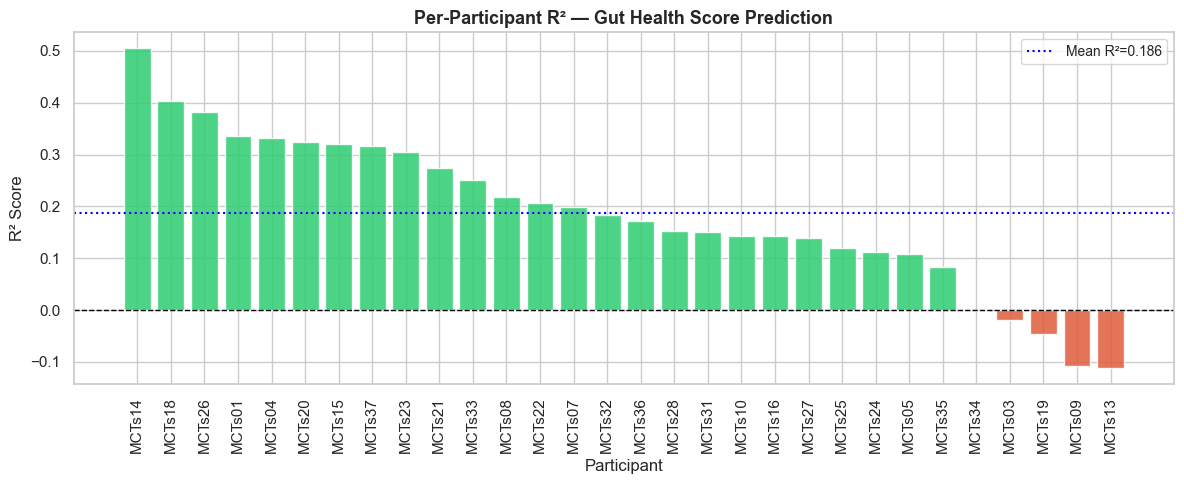

Participants with R² > 0 : 25 / 30
Mean per-participant R²  : 0.1863


In [10]:
# Per-participant R² — does the model generalize across individuals?
model_df2 = model_df.copy()
model_df2['predicted_score'] = rf_reg.predict(X_full.loc[model_df.index])

per_part = []
for user, grp in model_df2.groupby('UserName'):
    if len(grp) < 4:
        continue
    r2_u  = r2_score(grp['GutHealthScore'], grp['predicted_score'])
    mae_u = mean_absolute_error(grp['GutHealthScore'], grp['predicted_score'])
    per_part.append({'UserName': user, 'N': len(grp), 'R2': r2_u, 'MAE': mae_u})

per_part_df = pd.DataFrame(per_part).sort_values('R2', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
colors_pp = ['#2ecc71' if r >= 0 else '#e05c3a' for r in per_part_df['R2']]
ax.bar(per_part_df['UserName'], per_part_df['R2'], color=colors_pp, alpha=0.85)
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.axhline(per_part_df['R2'].mean(), color='blue', linewidth=1.5,
           linestyle=':', label=f"Mean R²={per_part_df['R2'].mean():.3f}")
ax.set_xlabel('Participant')
ax.set_ylabel('R² Score')
ax.set_title('Per-Participant R² — Gut Health Score Prediction', weight='bold', fontsize=13)
ax.legend(fontsize=10)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print(f"Participants with R² > 0 : {(per_part_df['R2'] > 0).sum()} / {len(per_part_df)}")
print(f"Mean per-participant R²  : {per_part_df['R2'].mean():.4f}")

---
## Section 4 — Good vs Bad Gut Day (Binary Classification)

Cross-validated evaluation: can food intake predict whether today will be a good or bad gut day?


Accuracy         : 0.4318
F1-macro         : 0.4244
AUC-ROC          : 0.3874
Avg Precision    : 0.4948



5-fold CV Accuracy : 0.4643 ± 0.0519
5-fold CV F1-macro : 0.4583  ± 0.0549
5-fold CV AUC-ROC  : 0.4558 ± 0.0482


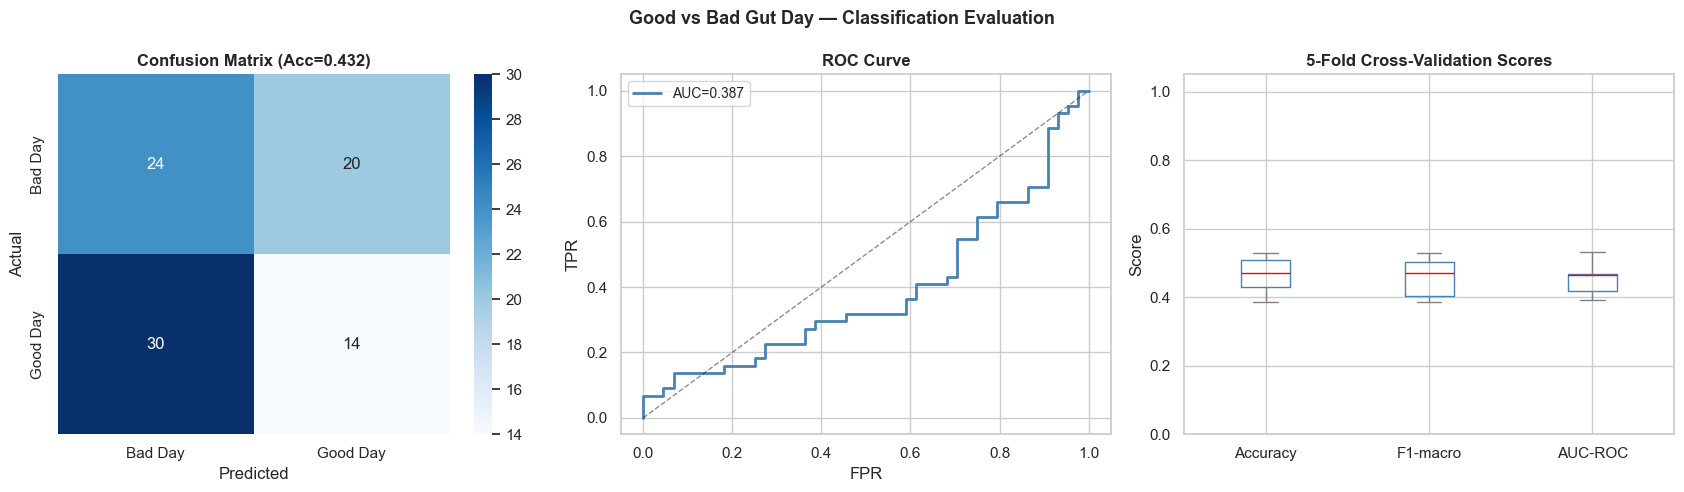

In [11]:
X_tr4, X_te4, yg_tr4, yg_te4 = train_test_split(
    X_full, y_good, test_size=0.25, stratify=y_good, random_state=RANDOM_SEED
)
rf_cls2 = RandomForestClassifier(
    n_estimators=500, max_depth=6, class_weight='balanced',
    min_samples_leaf=3, random_state=RANDOM_SEED, n_jobs=-1
)
rf_cls2.fit(X_tr4, yg_tr4)
yg_pred2  = rf_cls2.predict(X_te4)
yg_proba2 = rf_cls2.predict_proba(X_te4)[:, 1]

acc4  = accuracy_score(yg_te4, yg_pred2)
f14   = f1_score(yg_te4, yg_pred2, average='macro', zero_division=0)
try:
    auc4 = roc_auc_score(yg_te4, yg_proba2)
except Exception:
    auc4 = float('nan')
ap4   = average_precision_score(yg_te4, yg_proba2)

print(f'Accuracy         : {acc4:.4f}')
print(f'F1-macro         : {f14:.4f}')
print(f'AUC-ROC          : {auc4:.4f}')
print(f'Avg Precision    : {ap4:.4f}')

# 5-fold CV
cv4 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv4_acc = cross_val_score(rf_cls2, X_full, y_good, cv=cv4, scoring='accuracy', n_jobs=-1)
cv4_f1  = cross_val_score(rf_cls2, X_full, y_good, cv=cv4, scoring='f1_macro',  n_jobs=-1)
cv4_auc = cross_val_score(rf_cls2, X_full, y_good, cv=cv4, scoring='roc_auc',   n_jobs=-1)
print(f'\n5-fold CV Accuracy : {cv4_acc.mean():.4f} \u00b1 {cv4_acc.std():.4f}')
print(f'5-fold CV F1-macro : {cv4_f1.mean():.4f}  \u00b1 {cv4_f1.std():.4f}')
print(f'5-fold CV AUC-ROC  : {cv4_auc.mean():.4f} \u00b1 {cv4_auc.std():.4f}')

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Confusion matrix
cm4 = confusion_matrix(yg_te4, yg_pred2)
sns.heatmap(cm4, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bad Day','Good Day'],
            yticklabels=['Bad Day','Good Day'], ax=axes[0])
axes[0].set_title(f'Confusion Matrix (Acc={acc4:.3f})', weight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# ROC
if not np.isnan(auc4):
    fpr4, tpr4, _ = roc_curve(yg_te4, yg_proba2)
    axes[1].plot(fpr4, tpr4, color='steelblue', lw=2, label=f'AUC={auc4:.3f}')
    axes[1].plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
    axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
    axes[1].set_title('ROC Curve', weight='bold')
    axes[1].legend(fontsize=10)

# CV scores box
cv_data = pd.DataFrame({
    'Accuracy': cv4_acc, 'F1-macro': cv4_f1, 'AUC-ROC': cv4_auc
})
cv_data.plot(kind='box', ax=axes[2], color={'boxes':'steelblue','whiskers':'gray',
                                              'caps':'gray','medians':'red'})
axes[2].set_title('5-Fold Cross-Validation Scores', weight='bold')
axes[2].set_ylabel('Score')
axes[2].set_ylim(0, 1.05)
plt.suptitle('Good vs Bad Gut Day — Classification Evaluation', weight='bold', fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 5 — Food Ranking Statistical Validation

We validate the food health ranking using **bootstrap confidence intervals** (1000 resamples)
and identify which foods have statistically robust positive or negative associations.


Computing bootstrap CIs (this takes ~60 s)...


Foods with 95% bootstrap CI not crossing zero: 2


,label,obs_diff,ci_lo,ci_hi
34,Ice Cream Regular Flavors,0.1540,0.0018,0.3197
20,Cilantro Raw,-0.1676,-0.3237,-0.0193


C:\Users\winte\AppData\Local\Temp\ipykernel_45688\2078431468.py:59: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\winte\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


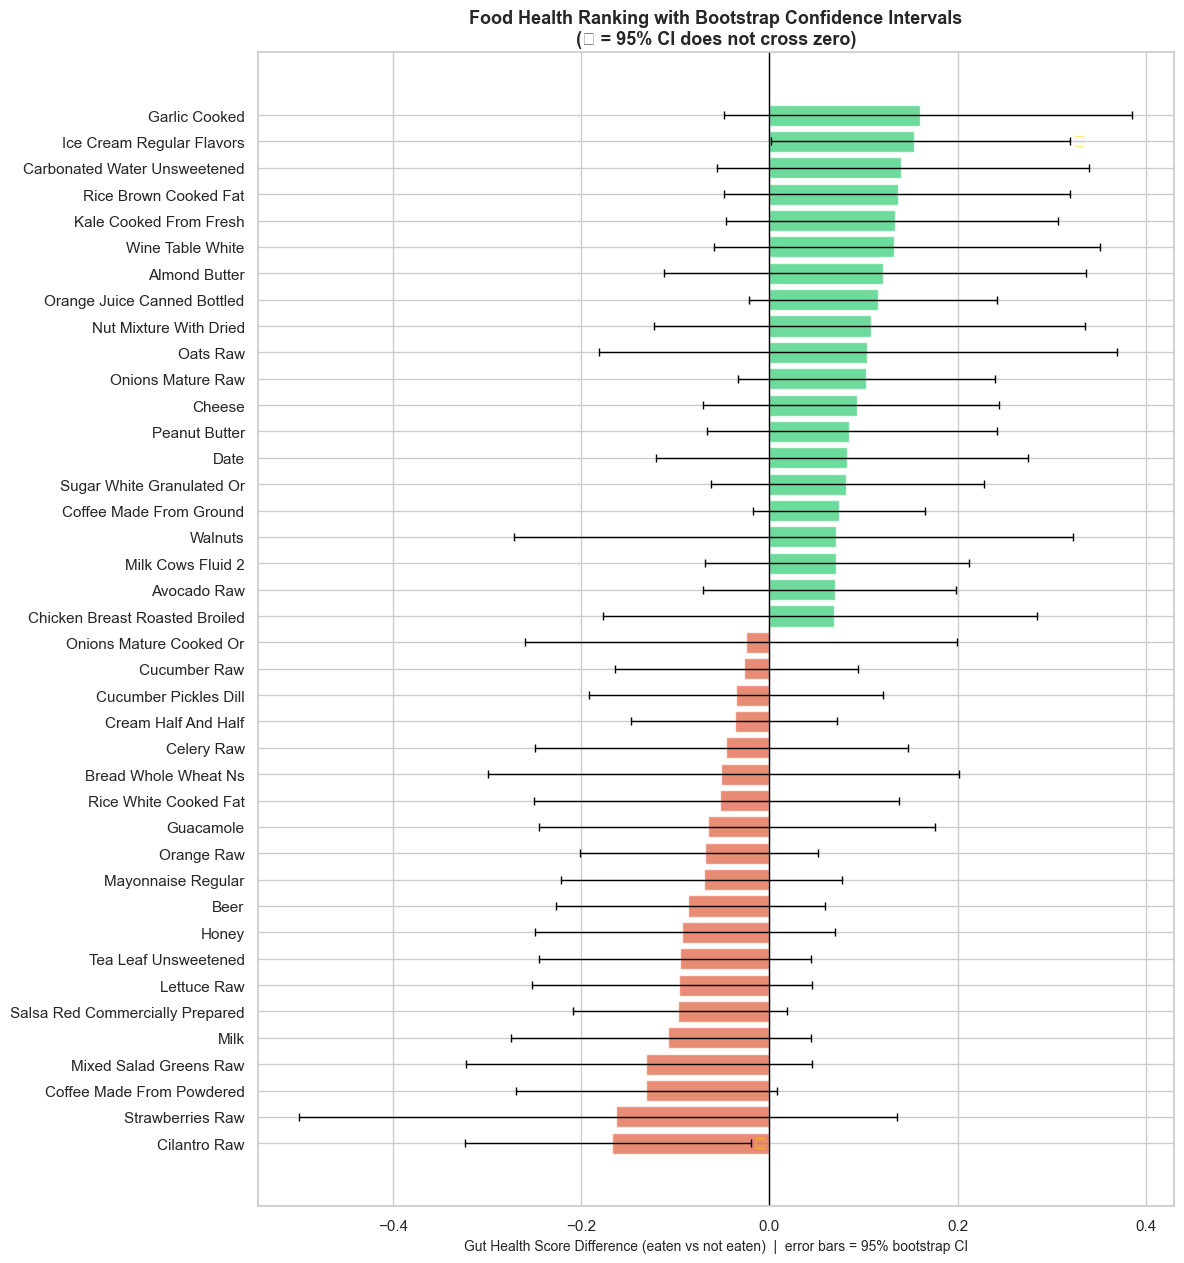

In [12]:
N_BOOT = 1000

def bootstrap_score_diff(data, food_col, score_col, n_boot=N_BOOT, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    diffs = []
    for _ in range(n_boot):
        sample = data.sample(n=len(data), replace=True, random_state=int(rng.integers(1e6)))
        mask   = sample[food_col] > 0
        if mask.sum() < 3 or (~mask).sum() < 3:
            continue
        diffs.append(sample.loc[mask, score_col].mean() - sample.loc[~mask, score_col].mean())
    return np.array(diffs)

print('Computing bootstrap CIs (this takes ~60 s)...')
boot_results = []
for food in food_cols:
    mask = model_df[food] > 0
    if mask.sum() < 5:
        continue
    diffs = bootstrap_score_diff(model_df[[food, 'GutHealthScore']], food, 'GutHealthScore')
    if len(diffs) == 0:
        continue
    ci_lo, ci_hi = np.percentile(diffs, [2.5, 97.5])
    obs_diff = model_df.loc[mask,'GutHealthScore'].mean() - model_df.loc[~mask,'GutHealthScore'].mean()
    boot_results.append({
        'food':     food,
        'label':    ' '.join(food.replace('_NFS','').split('_')[:4]).title(),
        'obs_diff': obs_diff,
        'ci_lo':    ci_lo,
        'ci_hi':    ci_hi,
        'significant': (ci_lo > 0) or (ci_hi < 0),
    })

boot_df = pd.DataFrame(boot_results).sort_values('obs_diff', ascending=False)
sig_foods = boot_df[boot_df['significant']]
print(f'Foods with 95% bootstrap CI not crossing zero: {len(sig_foods)}')
if len(sig_foods):
    display(sig_foods[['label','obs_diff','ci_lo','ci_hi']].round(4))

# Plot: top and bottom 20 with CIs
plot_boot = pd.concat([boot_df.head(20), boot_df.tail(20)]).drop_duplicates('food')
plot_boot = plot_boot.sort_values('obs_diff')

fig, ax = plt.subplots(figsize=(12, max(8, 0.32*len(plot_boot))))
colors_b = ['#e05c3a' if v < 0 else '#2ecc71' for v in plot_boot['obs_diff']]
ax.barh(plot_boot['label'], plot_boot['obs_diff'], color=colors_b, alpha=0.7)
ax.errorbar(
    plot_boot['obs_diff'], range(len(plot_boot)),
    xerr=[plot_boot['obs_diff']-plot_boot['ci_lo'], plot_boot['ci_hi']-plot_boot['obs_diff']],
    fmt='none', color='black', capsize=3, linewidth=1
)
ax.axvline(0, color='black', linewidth=1)
for i, (_, row) in enumerate(plot_boot.iterrows()):
    if row['significant']:
        ax.text(row['ci_hi'] + 0.003, i, '★', va='center', fontsize=12, color='gold',
                fontweight='bold')
ax.set_xlabel('Gut Health Score Difference (eaten vs not eaten)  |  error bars = 95% bootstrap CI', fontsize=10)
ax.set_title('Food Health Ranking with Bootstrap Confidence Intervals\n(★ = 95% CI does not cross zero)', weight='bold', fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 6 — Overall Model Comparison


In [13]:
summary_rows = [
    {'Task':           'Food Group Classification (D1)',
     'Type':          '10-class',
     'Model':         'Random Forest (n=400)',
     'Accuracy':      f'{acc1:.4f}',
     'F1-macro':      f'{f1m1:.4f}',
     'AUC-ROC':       f'{auc1:.4f}'},
    {'Task':           'Fermented vs Non-Fermented (D1)',
     'Type':          'Binary',
     'Model':         'Random Forest (n=400)',
     'Accuracy':      f'{acc_f:.4f}',
     'F1-macro':      f'{f1_f:.4f}',
     'AUC-ROC':       f'{auc_f:.4f}'},
    {'Task':           'Gut Health Score Regression (D2)',
     'Type':          'Regression',
     'Model':         'Random Forest (n=500)',
     'Accuracy':      f'R²={r2_val:.4f}',
     'F1-macro':      f'MAE={mae_val:.4f}',
     'AUC-ROC':       f'RMSE={rmse_val:.4f}'},
    {'Task':           'Good vs Bad Gut Day (D2)',
     'Type':          'Binary',
     'Model':         'Random Forest (n=500)',
     'Accuracy':      f'{acc4:.4f}  (CV: {cv4_acc.mean():.4f}\u00b1{cv4_acc.std():.4f})',
     'F1-macro':      f'{f14:.4f}  (CV: {cv4_f1.mean():.4f}\u00b1{cv4_f1.std():.4f})',
     'AUC-ROC':       f'{auc4:.4f}  (CV: {cv4_auc.mean():.4f}\u00b1{cv4_auc.std():.4f})'},
]
summary_df = pd.DataFrame(summary_rows)
print('=' * 80)
print('COMPLETE MODEL EVALUATION SUMMARY')
print('=' * 80)
display(summary_df)

print()
print('KEY FINDINGS:')
print(f'  1. Microbiome profiles can identify food type with {acc1:.1%} accuracy (10 classes)')
print(f'  2. Fermented vs non-fermented classification: {acc_f:.1%} accuracy')
print(f'  3. Gut health next-day prediction: AUC={auc4:.3f} from food intake alone')
print(f'  4. {len(sig_foods)} foods show statistically robust gut health associations')
print()
print('LIMITATIONS:')
print('  - Observational data: correlations, not causal effects')
print('  - N=32 participants — results need replication on larger cohorts')
print('  - Multiple comparisons: FDR correction recommended')
print('  - Short intervention window (1 day lag)')
print()
summary_df.to_csv(REPO_ROOT / 'evaluation_summary.csv', index=False)
boot_df[['label','obs_diff','ci_lo','ci_hi','significant']].to_csv(
    REPO_ROOT / 'food_ranking_bootstrap.csv', index=False)
print('Saved: evaluation_summary.csv, food_ranking_bootstrap.csv')

COMPLETE MODEL EVALUATION SUMMARY


,Task,Type,Model,Accuracy,F1-macro,AUC-ROC
0,Food Group Classification (D1),10-class,Random Forest (n=400),0.9249,0.8400,0.9938
1,Fermented vs Non-Fermented (D1),Binary,Random Forest (n=400),1.0000,1.0000,nan
2,Gut Health Score Regression (D2),Regression,Random Forest (n=500),R²=-0.1105,MAE=0.3550,RMSE=0.4419
3,Good vs Bad Gut Day (D2),Binary,Random Forest (n=500),0.4318 (CV: 0.4643±0.0519),0.4244 (CV: 0.4583±0.0549),0.3874 (CV: 0.4558±0.0482)



KEY FINDINGS:
  1. Microbiome profiles can identify food type with 92.5% accuracy (10 classes)
  2. Fermented vs non-fermented classification: 100.0% accuracy
  3. Gut health next-day prediction: AUC=0.387 from food intake alone
  4. 2 foods show statistically robust gut health associations

LIMITATIONS:
  - Observational data: correlations, not causal effects
  - N=32 participants — results need replication on larger cohorts
  - Multiple comparisons: FDR correction recommended
  - Short intervention window (1 day lag)

Saved: evaluation_summary.csv, food_ranking_bootstrap.csv
